稠密连接网络（DenseNet）是ResNet的逻辑扩展。

ResNet将函数展开为

$$f(\mathbf{x}) = \mathbf{x} + g(\mathbf{x}).$$

也就是说，ResNet将$f$分解为两部分：一个简单的线性项和一个复杂的非线性项。

将 f 拓展成超过两部分的信息，一种方案便是DenseNet。

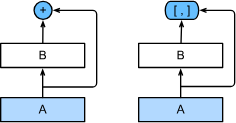

ResNet（左）与 DenseNet（右）在跨层连接上的主要区别：使用相加和使用连结。

ResNet和DenseNet的关键区别在于，DenseNet输出是连接而非简单相加

稠密网络主要由2部分构成：稠密块（dense block）和过渡层（transition layer）。 前者定义如何连接输入和输出，而后者则控制通道数量，使其不会太复杂。

稠密块体

DenseNet使用了ResNet改良版的“批量规范化、激活和卷积”架构

In [1]:
import torch
from torch import nn

def conv_block(input_channels, num_channels):
    return nn.Sequential(
        nn.BatchNorm2d(input_channels), nn.ReLU(),
        nn.Conv2d(input_channels, num_channels, kernel_size=3, padding=1))

一个稠密块由多个卷积块组成，每个卷积块使用相同数量的输出通道。

In [2]:
class DenseBlock(nn.Module):
    def __init__(self, num_convs, input_channels, num_channels):
        super(DenseBlock, self).__init__()
        layer = []
        for i in range(num_convs):
            layer.append(conv_block(
                num_channels * i + input_channels, num_channels))
        self.net = nn.Sequential(*layer)

    def forward(self, X):
        for blk in self.net:
            Y = blk(X)
            # 连接通道维度上每个块的输入和输出
            X = torch.cat((X, Y), dim=1)
        return X

卷积块的通道数控制了输出通道数相对于输入通道数的增长，因此也被称为增长率（growth rate）。

过渡层

每个稠密块都会带来通道数的增加，使用过多则会过于复杂化模型。 而过渡层可以用来控制模型复杂度。

通过 1×1 卷积层来减小通道数，并使用步幅为2的平均汇聚层减半高和宽

In [3]:
def transition_block(input_channels, num_channels):
    return nn.Sequential(
        nn.BatchNorm2d(input_channels), nn.ReLU(),
        nn.Conv2d(input_channels, num_channels, kernel_size=1),
        nn.AvgPool2d(kernel_size=2, stride=2))

DenseNet模型

DenseNet首先使用同ResNet一样的单卷积层和最大汇聚层。

In [4]:
b1 = nn.Sequential(
    nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3),
    nn.BatchNorm2d(64), nn.ReLU(),
    nn.MaxPool2d(kernel_size=3, stride=2, padding=1))

接下来，类似于ResNet使用的4个残差块，DenseNet使用的是4个稠密块。

每个稠密块使用四个卷积层，稠密块里的卷积层通道数（即增长率）设为32，所以每个稠密块将增加128个通道。

每个模块之间，使用过渡层来减半高和宽，并减半通道数。

In [5]:
# num_channels为当前的通道数
num_channels, growth_rate = 64, 32
num_convs_in_dense_blocks = [4, 4, 4, 4]
blks = []
for i, num_convs in enumerate(num_convs_in_dense_blocks):
    blks.append(DenseBlock(num_convs, num_channels, growth_rate))
    # 上一个稠密块的输出通道数
    num_channels += num_convs * growth_rate
    # 在稠密块之间添加一个转换层，使通道数量减半
    if i != len(num_convs_in_dense_blocks) - 1:
        blks.append(transition_block(num_channels, num_channels // 2))
        num_channels = num_channels // 2

最后接全局汇聚层和全连接层来输出结果。

In [6]:
net = nn.Sequential(
    b1, *blks,
    nn.BatchNorm2d(num_channels), nn.ReLU(),
    nn.AdaptiveAvgPool2d((1, 1)),
    nn.Flatten(),
    nn.Linear(num_channels, 10))

训练模型

In [7]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import time

# 超参数
lr, num_epochs, batch_size = 0.1, 10, 256

# 选择设备
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("training on", device)

# 数据预处理

transform = transforms.Compose([
    transforms.Resize((96, 96)),
    transforms.ToTensor()
])

# 下载数据集
train_dataset = datasets.FashionMNIST(
    root="./data",
    train=True,
    transform=transform,
    download=True
)

test_dataset = datasets.FashionMNIST(
    root="./data",
    train=False,
    transform=transform,
    download=True
)

# 数据加载器
train_iter = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
test_iter = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

# 计算准确率
def evaluate_accuracy_gpu(net, data_iter, device):
    net.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for X, y in data_iter:
            X, y = X.to(device), y.to(device)
            y_hat = net(X)
            correct += (y_hat.argmax(dim=1) == y).sum().item()
            total += y.numel()
    return correct / total

# 训练函数
def train_ch6(net, train_iter, test_iter, num_epochs, lr, device):
    net.to(device)
    optimizer = torch.optim.SGD(net.parameters(), lr=lr)
    loss = nn.CrossEntropyLoss()

    for epoch in range(num_epochs):
        net.train()
        metric_loss = 0.0
        metric_correct = 0
        metric_total = 0
        start = time.time()

        for X, y in train_iter:
            X, y = X.to(device), y.to(device)

            optimizer.zero_grad()
            y_hat = net(X)
            l = loss(y_hat, y)
            l.backward()
            optimizer.step()

            metric_loss += l.item() * X.shape[0]
            metric_correct += (y_hat.argmax(dim=1) == y).sum().item()
            metric_total += y.numel()

        train_loss = metric_loss / metric_total
        train_acc = metric_correct / metric_total
        test_acc = evaluate_accuracy_gpu(net, test_iter, device)

        print(f"epoch {epoch + 1}, "
              f"train loss {train_loss:.4f}, "
              f"train acc {train_acc:.4f}, "
              f"test acc {test_acc:.4f}, "
              f"time {time.time() - start:.1f} sec")

# 开始训练
train_ch6(net, train_iter, test_iter, num_epochs, lr, device)

training on cuda


100%|██████████| 26.4M/26.4M [00:01<00:00, 17.2MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 271kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.09MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 19.8MB/s]


epoch 1, train loss 0.4928, train acc 0.8270, test acc 0.7542, time 10.0 sec
epoch 2, train loss 0.2790, train acc 0.8980, test acc 0.8284, time 8.4 sec
epoch 3, train loss 0.2392, train acc 0.9127, test acc 0.7661, time 8.4 sec
epoch 4, train loss 0.2111, train acc 0.9215, test acc 0.8041, time 8.8 sec
epoch 5, train loss 0.1920, train acc 0.9292, test acc 0.8367, time 8.5 sec
epoch 6, train loss 0.1767, train acc 0.9340, test acc 0.9072, time 8.4 sec
epoch 7, train loss 0.1623, train acc 0.9411, test acc 0.8761, time 8.4 sec
epoch 8, train loss 0.1491, train acc 0.9457, test acc 0.8547, time 8.7 sec
epoch 9, train loss 0.1389, train acc 0.9491, test acc 0.8891, time 8.7 sec
epoch 10, train loss 0.1278, train acc 0.9537, test acc 0.9063, time 8.4 sec


## 练习

1. 为什么我们在过渡层使用平均汇聚层而不是最大汇聚层？

在 DenseNet 的过渡层中使用平均池化而不是最大池化，是为了更好地保留特征信息。最大池化会选择局部区域中的最大值，从而丢弃其他特征信息，而 DenseNet 的核心思想是特征复用，即后续层会利用前面所有层的特征。

因此，如果使用最大池化，会导致部分重要信息被丢失，不利于特征传递。

1. DenseNet的优点之一是其模型参数比ResNet小。为什么呢？

DenseNet 的参数量比 ResNet 小，主要是因为其采用了特征复用的机制。在 DenseNet 中，每一层都将之前所有层的输出作为输入，并通过拼接的方式保留这些特征，因此后续层可以直接利用已有特征，而无需重复学习相同的信息。

1. DenseNet一个诟病的问题是内存或显存消耗过多。
    1. 真的是这样吗？可以把输入形状换成$224 \times 224$，来看看实际的显存消耗。
    1. 有另一种方法来减少显存消耗吗？需要改变框架么？

In [9]:
# 数据预处理

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

net = nn.Sequential(
    b1, *blks,
    nn.BatchNorm2d(num_channels), nn.ReLU(),
    nn.AdaptiveAvgPool2d((1, 1)),
    nn.Flatten(),
    nn.Linear(num_channels, 10))

In [11]:
# ================= 显存测试 =================
import torch
from torch import nn

net = net.to(device)
net.train()

# 构造一个 batch（用你的 batch_size）
X = torch.randn(batch_size, 1, 224, 224, device=device)
y = torch.randint(0, 10, (batch_size,), device=device)

loss_fn = nn.CrossEntropyLoss()

if device.type == "cuda":
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()

# 前向传播
y_hat = net(X)
loss = loss_fn(y_hat, y)

if device.type == "cuda":
    print("前向传播后：")
    print(f"当前显存: {torch.cuda.memory_allocated()/1024**2:.2f} MB")
    print(f"缓存显存: {torch.cuda.memory_reserved()/1024**2:.2f} MB")

# 反向传播
loss.backward()

if device.type == "cuda":
    print("\n反向传播后：")
    print(f"当前显存: {torch.cuda.memory_allocated()/1024**2:.2f} MB")
    print(f"缓存显存: {torch.cuda.memory_reserved()/1024**2:.2f} MB")
    print(f"峰值显存: {torch.cuda.max_memory_allocated()/1024**2:.2f} MB")

前向传播后：
当前显存: 8005.36 MB
缓存显存: 9514.00 MB

反向传播后：
当前显存: 72.43 MB
缓存显存: 12068.00 MB
峰值显存: 8028.84 MB


In [12]:
train_ch6(net, train_iter, test_iter, num_epochs, lr, device)

epoch 1, train loss 0.1825, train acc 0.9504, test acc 0.8039, time 8.7 sec
epoch 2, train loss 0.1196, train acc 0.9586, test acc 0.8542, time 8.9 sec
epoch 3, train loss 0.1072, train acc 0.9615, test acc 0.7750, time 8.8 sec
epoch 4, train loss 0.0996, train acc 0.9636, test acc 0.8521, time 8.7 sec
epoch 5, train loss 0.0904, train acc 0.9676, test acc 0.7568, time 8.5 sec
epoch 6, train loss 0.0855, train acc 0.9700, test acc 0.9102, time 8.7 sec
epoch 7, train loss 0.0738, train acc 0.9737, test acc 0.8542, time 8.8 sec
epoch 8, train loss 0.0684, train acc 0.9752, test acc 0.8911, time 8.5 sec
epoch 9, train loss 0.0635, train acc 0.9776, test acc 0.8995, time 8.4 sec
epoch 10, train loss 0.0562, train acc 0.9806, test acc 0.8816, time 8.5 sec


In [13]:
!nvidia-smi

Mon Mar 30 05:13:33 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   40C    P0             78W /  400W |   12604MiB /  40960MiB |     22%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

实验结果表明，DenseNet 在训练过程中，尤其是在反向传播阶段，显存占用显著增加。这是因为 DenseNet 采用特征拼接（concatenation）的方式，每一层都会保留之前所有层的特征图，导致中间激活值数量不断增长。因此，虽然 DenseNet 的参数量较小，但其显存消耗确实较高。

1. 实现DenseNet论文 :cite:`Huang.Liu.Van-Der-Maaten.ea.2017`表1所示的不同DenseNet版本。

In [16]:
transform = transforms.Compose([
    transforms.Resize((96, 96)),
    transforms.ToTensor()
])

In [14]:
def build_densenet(blocks, growth_rate=32, num_classes=10):
    num_channels = 64

    b1 = nn.Sequential(
        nn.Conv2d(1, num_channels, kernel_size=7, stride=2, padding=3),
        nn.BatchNorm2d(num_channels),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
    )

    layers = []
    for i, num_convs in enumerate(blocks):
        layers.append(DenseBlock(num_convs, num_channels, growth_rate))
        num_channels += num_convs * growth_rate

        if i != len(blocks) - 1:
            layers.append(transition_block(num_channels, num_channels // 2))
            num_channels = num_channels // 2

    net = nn.Sequential(
        b1,
        *layers,
        nn.BatchNorm2d(num_channels),
        nn.ReLU(),
        nn.AdaptiveAvgPool2d((1, 1)),
        nn.Flatten(),
        nn.Linear(num_channels, num_classes)
    )

    return net

实现DenseNet-121

In [17]:
net121 = build_densenet([6, 12, 24, 16], growth_rate=32)

In [18]:
train_ch6(net121, train_iter, test_iter, num_epochs, lr, device)

epoch 1, train loss 0.4840, train acc 0.8192, test acc 0.7540, time 19.7 sec
epoch 2, train loss 0.2664, train acc 0.9009, test acc 0.8624, time 19.3 sec
epoch 3, train loss 0.2189, train acc 0.9183, test acc 0.7992, time 19.3 sec
epoch 4, train loss 0.1909, train acc 0.9283, test acc 0.8810, time 19.3 sec
epoch 5, train loss 0.1655, train acc 0.9386, test acc 0.8845, time 19.3 sec
epoch 6, train loss 0.1488, train acc 0.9443, test acc 0.8866, time 19.3 sec
epoch 7, train loss 0.1314, train acc 0.9498, test acc 0.8973, time 19.3 sec
epoch 8, train loss 0.1155, train acc 0.9569, test acc 0.8966, time 19.3 sec
epoch 9, train loss 0.1057, train acc 0.9603, test acc 0.9212, time 19.3 sec
epoch 10, train loss 0.0890, train acc 0.9668, test acc 0.8371, time 19.3 sec


实现DenseNet-169

In [19]:
net169 = build_densenet([6, 12, 32, 32], growth_rate=32)

In [20]:
train_ch6(net169, train_iter, test_iter, num_epochs, lr, device)

epoch 1, train loss 0.5817, train acc 0.7885, test acc 0.8473, time 24.6 sec
epoch 2, train loss 0.2820, train acc 0.8933, test acc 0.8014, time 24.3 sec
epoch 3, train loss 0.2297, train acc 0.9145, test acc 0.8779, time 24.4 sec
epoch 4, train loss 0.1928, train acc 0.9280, test acc 0.8311, time 24.3 sec
epoch 5, train loss 0.1739, train acc 0.9348, test acc 0.8691, time 24.4 sec
epoch 6, train loss 0.1485, train acc 0.9453, test acc 0.8163, time 24.4 sec
epoch 7, train loss 0.1367, train acc 0.9486, test acc 0.8375, time 24.4 sec
epoch 8, train loss 0.1175, train acc 0.9567, test acc 0.8976, time 24.3 sec
epoch 9, train loss 0.1067, train acc 0.9593, test acc 0.8578, time 24.4 sec
epoch 10, train loss 0.0920, train acc 0.9649, test acc 0.8837, time 24.4 sec


DenseNet-201

In [21]:
net201 = build_densenet([6, 12, 48, 32], growth_rate=32)

In [22]:
train_ch6(net201, train_iter, test_iter, num_epochs, lr, device)

epoch 1, train loss 0.7248, train acc 0.7554, test acc 0.7678, time 32.0 sec
epoch 2, train loss 0.3158, train acc 0.8821, test acc 0.8329, time 31.8 sec
epoch 3, train loss 0.2483, train acc 0.9083, test acc 0.7869, time 31.8 sec
epoch 4, train loss 0.2152, train acc 0.9195, test acc 0.8837, time 31.9 sec
epoch 5, train loss 0.1879, train acc 0.9299, test acc 0.8968, time 31.9 sec
epoch 6, train loss 0.2880, train acc 0.9032, test acc 0.8751, time 31.9 sec
epoch 7, train loss 0.1732, train acc 0.9356, test acc 0.8815, time 31.8 sec
epoch 8, train loss 0.1481, train acc 0.9444, test acc 0.8960, time 31.9 sec
epoch 9, train loss 0.1319, train acc 0.9503, test acc 0.8526, time 31.9 sec
epoch 10, train loss 0.1215, train acc 0.9543, test acc 0.8994, time 31.9 sec


根据 DenseNet 论文 Table 1，可以通过调整每个 dense block 中的卷积层数量来构建不同的 DenseNet 变体。

通过编写一个通用的 build_densenet(blocks) 函数，根据不同配置生成对应模型。实验表明，随着网络深度增加，模型表达能力增强，但计算量和显存消耗也显著增加。